## FCLGA GraphTransformer: Linear Demo

This notebook demonstrated the complete FCLGA workflow for CFRP Strain Field Prediction on a Linear Elastic Laminate.

1. **Environment Setup** Verify the conda environment is activated and ready.
2. **Preprocessing pipeline:** 6-step pipeline generating 500 parametric samples.
3. **Training:** Hyperparameter optimized training.  
4. **Testing:** Evaluation on test set. 
5. **Results:** Display of strain field predictions.


## Step 1: Environment Setup

In [1]:
# Setup: Change to project root directory
import os
from pathlib import Path

# Get project root (parent of notebooks/)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(PROJECT_ROOT)
print(f"✓ Working directory: {PROJECT_ROOT}")

# Verify environment
import sys
print(f"✓ Python: {sys.version.split()[0]}")
print(f"✓ Conda environment: {Path(sys.prefix).name}")

import torch
import torch_geometric
print(f"✓ PyTorch: {torch.__version__}")
print(f"✓ PyTorch Geometric: {torch_geometric.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")

✓ Working directory: /home/lpatrign/HybridAttentionGNN
✓ Python: 3.10.19
✓ Conda environment: fclga


/home/lpatrign/miniconda3/envs/fclga/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ PyTorch: 2.9.1+cu128
✓ PyTorch Geometric: 2.7.0
✓ CUDA available: True


## Step 2: Preprocessing Pipeline

In [ ]:
# Step 2.1: Generate geometries
!abaqus cae nogui=src/preprocessing/linear/fclga_generate_geometry.py

Abaqus License Manager checked out the following license:
"cae" from Flexnet server abaqus-research.cc.ic.ac.uk
<56 out of 57 licenses remain available>.


In [83]:
# Step 2.2: Run simulations (Static/Implicit)
!python -m src.preprocessing.linear.fclga_run_simulations

ELASTIC CASE: RUNNING ABAQUS SIMULATIONS
Found 500 geometry files to simulate
Input directory: /home/lpatrign/HybridAttentionGNN/data/raw/linear/geometry
Output directory: /home/lpatrign/HybridAttentionGNN/data/raw/linear/simulations

Running 500 simulations with 4 parallel workers

--------------------------------------------------------------------------------
Starting Abaqus job: Plate_linear_0
Starting Abaqus job: Plate_linear_1
Starting Abaqus job: Plate_linear_10
Starting Abaqus job: Plate_linear_100
Analysis initiated from SIMULIA established products
Abaqus JOB Plate_linear_1
Abaqus 2024.HF3
Analysis initiated from SIMULIA established products
Abaqus JOB Plate_linear_0
Abaqus 2024.HF3
Analysis initiated from SIMULIA established products
Abaqus JOB Plate_linear_100
Abaqus 2024.HF3
Analysis initiated from SIMULIA established products
Abaqus JOB Plate_linear_10
Abaqus 2024.HF3
Abaqus License Manager checked out the following licenses:
Abaqus/Standard checked out 5 tokens from Flex

In [96]:
# Step 2.3: Extract strains
!abaqus cae nogui=src/preprocessing/linear/fclga_extract_results.py

Abaqus License Manager checked out the following license:
"cae" from Flexnet server abaqus-research.cc.ic.ac.uk
<55 out of 57 licenses remain available>.


In [97]:
# Step 2.4: Extract features
!python -m src.preprocessing.linear.fclga_extract_features

ELASTIC CASE: EXTRACTING FEATURES FROM .INP FILES
Found 500 .inp files
--------------------------------------------------------------------------------
Processed 1/500: Plate_linear_0.inp (1230 nodes)
Processed 50/500: Plate_linear_49.inp (1210 nodes)
Processed 100/500: Plate_linear_99.inp (1189 nodes)
Processed 150/500: Plate_linear_149.inp (1180 nodes)
Processed 200/500: Plate_linear_199.inp (1243 nodes)
Processed 250/500: Plate_linear_249.inp (1220 nodes)
Processed 300/500: Plate_linear_299.inp (1180 nodes)
Processed 350/500: Plate_linear_349.inp (1225 nodes)
Processed 400/500: Plate_linear_399.inp (1243 nodes)
Processed 450/500: Plate_linear_449.inp (1235 nodes)
Processed 500/500: Plate_linear_499.inp (1207 nodes)
--------------------------------------------------------------------------------
Maximum node count: 1244
Padding to: 1245 (max_node_count + 1)
✓ Node data saved to: /home/lpatrign/HybridAttentionGNN/data/processed/linear/node_gnn_data.pt
✓ Triangulation data saved to: /h

In [98]:
# Step 2.5: Build dataset
!python -m src.preprocessing.linear.fclga_build_dataset

ELASTIC CASE: BUILDING STRAIN DATASET
Reading strain files from: /home/lpatrign/HybridAttentionGNN/data/interim/linear/strains
Reading node data from: /home/lpatrign/HybridAttentionGNN/data/processed/linear
Output will be saved to: /home/lpatrign/HybridAttentionGNN/data/processed/linear
Loaded 500 samples from node GNN data

Processing 500 strain files...
  Processing sample 1/500: E11_Plate_linear_0.txt
    INFO: 15/1245 nodes have no strain data (expected for boundary nodes)
    INFO: 15/1245 nodes have no strain data (expected for boundary nodes)
    INFO: 15/1245 nodes have no strain data (expected for boundary nodes)
  Processing sample 100/500: E11_Plate_linear_99.txt
  Processing sample 200/500: E11_Plate_linear_199.txt
  Processing sample 300/500: E11_Plate_linear_299.txt
  Processing sample 400/500: E11_Plate_linear_399.txt
  Processing sample 500/500: E11_Plate_linear_499.txt

DATASET BUILDING COMPLETE
✓ Saved strain tensor to: /home/lpatrign/HybridAttentionGNN/data/processed

In [99]:
# Step 2.6: Prepare training data
!python -m src.preprocessing.linear.fclga_prepare_training_data

ELASTIC CASE: FCLGA Training Data Preparation
Loading preprocessed data...
✓ Loaded 500 graph samples
✓ Loaded 500 strain samples
✓ Loaded geometry data: torch.Size([500, 6])

Processing 500 samples...
Graph is already bidirectional.
  Processing sample 1/500...

First sample statistics:
  Geometry: L=171.19, W=191.68, radius=18.34, displacement=1.0000
  Hole edge nodes: 20.0
  Fixed boundary nodes: 50
  Displaced boundary nodes: 35
  Distance tolerance: 0.9171
  Processing sample 100/500...
  Processing sample 200/500...
  Processing sample 300/500...
  Processing sample 400/500...
  Processing sample 500/500...
✓ Processed all 500 samples

✓ Saved processed data to: /home/lpatrign/HybridAttentionGNN/data/processed/linear/datasets/processed_data.pt

Data Summary
Number of samples: 500
Node features: [x, y, is_hole_edge, is_fixed, is_displaced, displacement_amount]
Node feature shape: torch.Size([1245, 6])
Edge index shape: torch.Size([2, 7084])
Edge attribute shape: torch.Size([7084, 

## Step 3: Training


In [2]:
# Train with hyperparameter optimization

# python -m src.training.fclga_train_model \
#     --material_type linear \
#     --optimize \
#     --optuna_trials 25 \
#     --epochs 50 \
#     --final_epochs 500 \
#     2>&1 | tee notebooks/train_linear.log

# Display the log from the previous run:
from pathlib import Path

log_file = Path("notebooks/train_linear.log")
if log_file.exists():
    log_content = log_file.read_text()
    print(log_content[-2000:])

...
Ground truth range: 0.000000 to 0.024674
Prediction range: 0.001937 to 0.024217
Nominal error range: 0.000000 to 0.015410
Element-wise ground truth range: 0.002054 to 0.022091
Element-wise prediction range: 0.002194 to 0.021903
Saved test set prediction comparison: /home/lpatrign/HybridAttentionGNN/results/linear/training_linear_20260109_133920/training_results/test_set_prediction_
comparison_data/test_set_prediction_comparison.pdf
Original data points: 1245
Filtered data points (actual strain > 1e-06): 1189
Removed 56 padded/near-zero nodes
R-squared (R²): 0.9951
RMSE: 0.000149
Regression plot saved to /home/lpatrign/HybridAttentionGNN/results/linear/training_linear_20260109_133920/training_results/test_set_prediction_comparison_da
ta/test_set_prediction_comparison_regression.pdf
Metrics saved to /home/lpatrign/HybridAttentionGNN/results/linear/training_linear_20260109_133920/training_results/test_set_prediction_comparison_data/test_
set_prediction_comparison_metrics.txt

Final Te

## Step 4: Testing

Using `--training_run` to specify results folder.

**Estimated time:** ~5 minutes

In [10]:
# Test - update timestamp with your training run
!python -m src.evaluation.fclga_test \
    --training_run results/linear/training_linear_20260109_133920 \
    --material_type linear

AUTO-LOADING FROM TRAINING RUN
Training run directory: results/linear/training_linear_20260109_133920

Loading hyperparameters from: results/linear/training_linear_20260109_133920/hyperparameter_optimization_results/best_hyperparameters.json
Found final trained model: model_nl8_bs4_hd64_ep500_wd4.0065526214425986e-05_lr0.000500931266717618_shuff_True_tr350_te75_FINAL.pt

Loaded hyperparameters:
  num_layers: 8
  attention_freq: 7
  batch_size: 4
  hidden_dim: 64
  dropout_rate: 0.1276462318375238
  opt: rmsprop
  opt_decay_step: 71
  opt_decay_rate: 0.6750979064513736
  weight_decay: 4.0065526214425986e-05
  lr: 0.000500931266717618

✓ Hyperparameters and model path loaded successfully!

FCLGA GRAPHTRANSFORMER - MODEL TESTING

Model checkpoint: results/linear/training_linear_20260109_133920/best_models/model_nl8_bs4_hd64_ep500_wd4.0065526214425986e-05_lr0.000500931266717618_shuff_True_tr350_te75_FINAL.pt
Device: cuda
Loading dataset from: /home/lpatrign/HybridAttentionGNN/data/processe

## Step 5: View Results

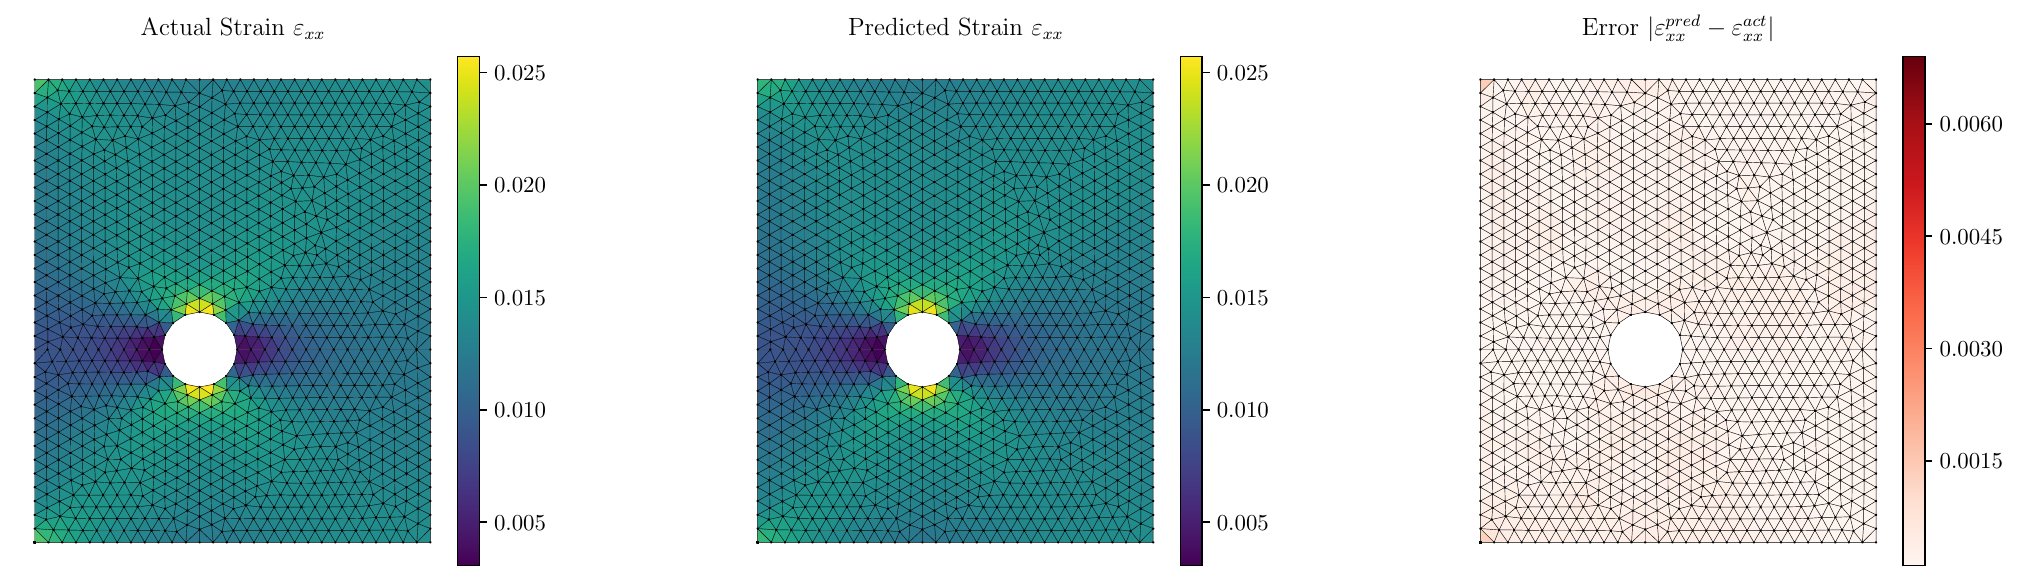

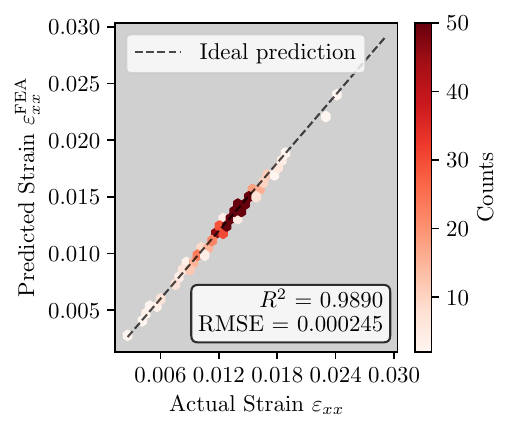

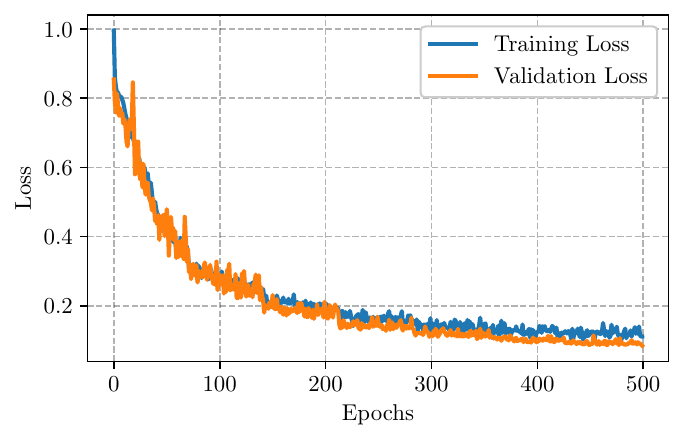

In [12]:
# Display test results
from pathlib import Path
from IPython.display import display, Image, HTML
import subprocess

training_run = "results/linear/training_linear_20260109_133920"

# Find training losses PDF
losses_dir = Path(training_run) / "training_results"
losses_pdf = list(losses_dir.glob("Losses_*.pdf"))[0] if losses_dir.exists() and list(losses_dir.glob("Losses_*.pdf")) else None

pdfs = [
    ("Strain Field Prediction", 
     Path(training_run) / "test_results/test_sample_4_results_data/test_sample_4_results.pdf", 
     800),
    ("Regression Analysis", 
     Path(training_run) / "test_results/test_sample_4_results_data/test_sample_4_results_regression.pdf", 
     450),
    ("Training Loss Curves", losses_pdf, 800)
]

def show_pdf(pdf_path, title, width):
    if pdf_path is None or not pdf_path.exists():
        return False
    
    png_path = pdf_path.with_suffix('.png')
    result = subprocess.run(
        ['pdftoppm', '-png', '-singlefile', '-r', '150', str(pdf_path), str(png_path.with_suffix(''))],
        capture_output=True, text=True
    )
    
    if result.returncode == 0 and png_path.exists():
        display(HTML(f"<h3 style='margin: 30px 0 10px 0; color: #2196F3;'>{title}</h3>"))
        display(Image(filename=str(png_path), width=width))
        return True
    return False

display(HTML("<h2 style='color: #4CAF50;'>Test Results & Training Metrics</h2>"))

for title, path, width in pdfs:
    show_pdf(path, title, width)